# Compare behavioral sessions

Loads all participant/session folders under `data/beh/raw/`, plots each independently, then compares them on one plot (colored scatter, median/mean markers, and a 1-std covariance ellipse per session), and quantifies the difference between sessions with both a centroid distance and a spread-aware Mahalanobis distance.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from src.beh.io import load_session
from src.beh.analysis import compute_session_summary, compute_session_distances
from src.beh.plotting import plot_session_cloud, plot_sessions_comparison

## 1. Load all sessions and compute summaries

In [2]:
raw_dir = repo_root / "data" / "beh" / "raw"
session_names = sorted(p.name for p in raw_dir.iterdir() if p.is_dir())

sessions = {name: load_session(raw_dir / name) for name in session_names}
summaries = {name: compute_session_summary(df) for name, df in sessions.items()}
session_names

['test2', 'test3', 'testUpstairs_18_JUN_26']

## 2. Each session independently

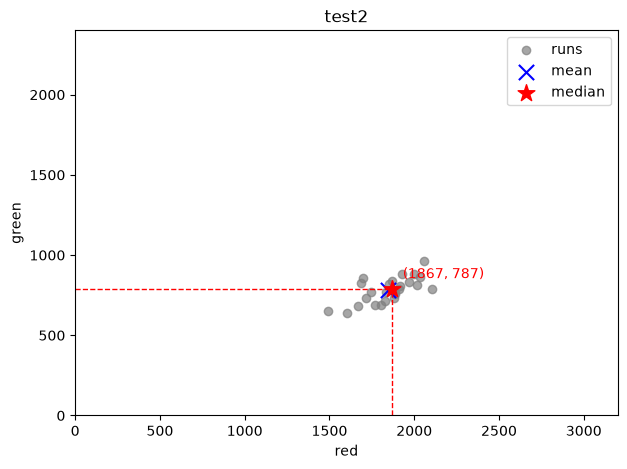

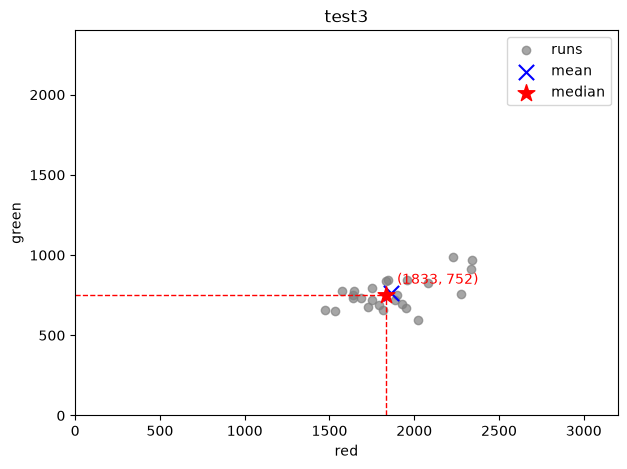

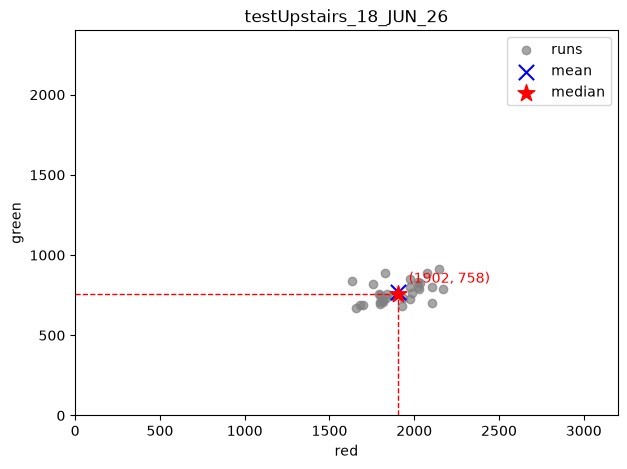

In [3]:
for name in session_names:
    ax = plot_session_cloud(sessions[name], summary=summaries[name])
    ax.set_title(name)
    plt.show()

## 3. All sessions together

<Axes: xlabel='red', ylabel='green'>

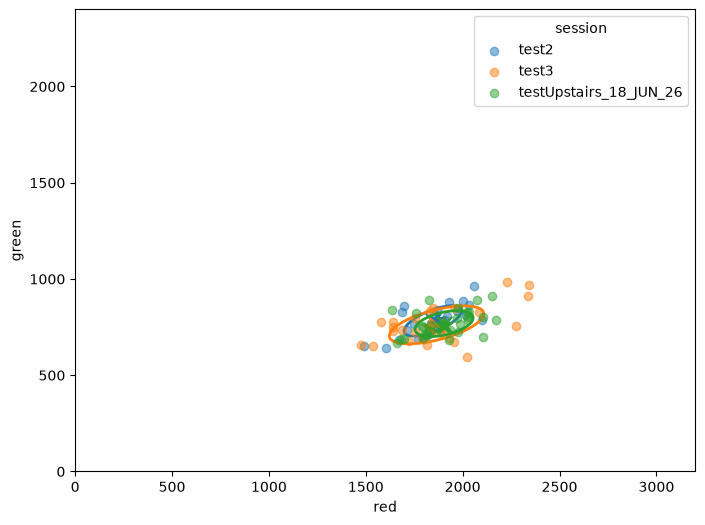

In [4]:
plot_sessions_comparison(sessions, summaries)

## 4. Quantify the difference between sessions

`centroidDistance` is the Euclidean distance between each pair of sessions' median points. `mahalanobisDistance` accounts for each session's spread (covariance), not just its center.

In [5]:
compute_session_distances(sessions, summaries)

,sessionA,sessionB,centroidDistance,mahalanobisDistance
0,test2,test3,48.795492,0.375006
1,test2,testUpstairs_18_JUN_26,44.749302,0.598135
2,test3,testUpstairs_18_JUN_26,68.807703,0.197522
